In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score
import time
import matplotlib.pyplot as plt

# 导入你写好的 dataset 和 model 模块
from dataset import get_dataloader
from modelV5 import ShareBottom_PEPNet

# 检测算力设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 当前训练运行在: {device} 算力设备上")

🚀 当前训练运行在: cuda 算力设备上


## 参数设置

In [ ]:
# --- 1. 路径配置 ---
# 请确保这里的路径与你 opendata_V2_success.ipynb 生成的路径一致
vocab_json_path = '/root/autodl-tmp/Sharebottom_PEPNet/datapreprocess/workspace/processed/vocab_sizes.json'
train_parquet = '/root/autodl-tmp/Sharebottom_PEPNet/datapreprocess/workspace/processed/train_model_input.parquet'
test_parquet = '/root/autodl-tmp/Sharebottom_PEPNet/datapreprocess/workspace/processed/test_model_input.parquet'

# --- 2. 核心超参数 ---
BATCH_SIZE = 2048
EPOCHS = 5
LEARNING_RATE = 5e-4
EMBED_DIM = 32          # 推荐升级到 32 维以获取更强的表征能力
BOTTOM_DROPOUT = 0    # Click 塔防过拟合
CVR_DROPOUT = 0.05   # CVR 塔适度正则化，防止过拟合

## 定义验证集评估函数

In [3]:
def evaluate_model(model, dataloader, device):
    """在验证集上评估模型，返回 CTR 和 CVR 的 AUC"""
    model.eval() # 开启评估模式
    ctr_preds, cvr_preds = [], []
    ctr_labels, cvr_labels = [], []
    
    with torch.no_grad(): # 关闭梯度计算，节省显存并加速
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            click_prob, cvr_prob = model(batch)
            
            # 收集预测概率和真实标签
            ctr_preds.extend(click_prob.cpu().numpy())
            cvr_preds.extend(cvr_prob.cpu().numpy())
            ctr_labels.extend(batch['click'].cpu().numpy())
            cvr_labels.extend(batch['conversion'].cpu().numpy())
            
    # 计算 AUC (加入 try-except 防止纯负样本 Batch 导致 sklearn 报错)
    try:
        ctr_auc = roc_auc_score(ctr_labels, ctr_preds)
    except:
        ctr_auc = 0.0
    try:
        cvr_auc = roc_auc_score(cvr_labels, cvr_preds)
    except:
        cvr_auc = 0.0
        
    return ctr_auc, cvr_auc

## 加载数据与初始化模型

In [4]:
print("📦 正在挂载 Parquet 数据集到 DataLoader...")
train_loader = get_dataloader(train_parquet, batch_size=BATCH_SIZE, shuffle=True)
test_loader = get_dataloader(test_parquet, batch_size=BATCH_SIZE, shuffle=False)
print(f"✅ 训练集 Batch 数量: {len(train_loader)} | 测试集 Batch 数量: {len(test_loader)}")

print("\n🧠 正在实例化 ShareBottom_PEPNet 模型...")
model = ShareBottom_PEPNet(
    vocab_json_path=vocab_json_path, 
    embed_dim=EMBED_DIM, 
    shared_bottom_units=[256, 128], 
    cvr_tower_units=[128, 64],
    bottom_dropout=BOTTOM_DROPOUT,
    cvr_dropout=CVR_DROPOUT
).to(device)

# --- 定义损失函数、优化器与调度器 ---
criterion = nn.BCELoss(reduction='none') 
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5) # 余弦退火调度器

print("✅ 模型、优化器初始化完成！准备起飞。")

📦 正在挂载 Parquet 数据集到 DataLoader...


✅ 训练集 Batch 数量: 733 | 测试集 Batch 数量: 733

🧠 正在实例化 ShareBottom_PEPNet 模型...
✅ 模型、优化器初始化完成！准备起飞。


何恺明为了解决极度不平衡问题引入动态衰减：模型一旦发现某个样本自己已经猜得很准了（比如大量无聊的负样本），就会把它的 Loss 压缩到接近 0；强迫模型把所有精力（梯度）都花在那些“很难猜的稀疏正样本”上。
引入 Focal Loss 替换硬核加权（平稳 Loss 差距）

In [5]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        """
        alpha: 正负样本的平衡权重。CVR正样本极少，建议调用时给正样本极高的 alpha (如 0.9)
        gamma: 聚焦参数，越大越能把简单负样本的 loss 压死 (推荐 2.0)
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        # preds: [Batch], targets: [Batch]
        # 确保预测值在安全范围内，避免 log(0)
        preds = torch.clamp(preds, min=1e-7, max=1-1e-7)
        
        # BCE 原始 Loss
        bce_loss = - (targets * torch.log(preds) + (1 - targets) * torch.log(1 - preds))
        
        # 计算预测正确的概率 p_t
        p_t = targets * preds + (1 - targets) * (1 - preds)
        
        # 动态 alpha 权重
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        
        # Focal Loss 核心公式: alpha_t * (1 - p_t)^gamma * BCE
        focal_loss = alpha_t * torch.pow((1 - p_t), self.gamma) * bce_loss
        
        return focal_loss.mean()

## 执行核心训练大循环

In [ ]:

import time
import torch

# ==========================================
# 1. 初始化专用 Loss 评价器
# ==========================================
# CTR 任务：正样本约 4%，设 alpha=0.75 稍微提权
criterion_ctr = FocalLoss(alpha=0.75, gamma=2.0)
# CVR 任务：正样本仅万分之三，设 alpha=0.95 给予绝对的重视
criterion_cvr = FocalLoss(alpha=0.95, gamma=2.0) 

# ==========================================
# 2. 核心训练大循环 (包含早停机制)
# ==========================================
print("🔥 开始训练流...\n")

# 用于记录绘图的历史数据
history = {'loss_ctr': [], 'loss_cvr': [], 'auc_ctr': [], 'auc_cvr': []}
total_steps = len(train_loader)

# 早停机制相关变量初始化
best_auc_sum = 0.0       # 记录历史最高的 AUC 之和 (CTR_AUC + CVR_AUC)
patience = 2             # 容忍度：连续 2 个 Epoch 没提升就停止
patience_counter = 0     # 连续未提升的 Epoch 计数器
best_epoch = 0           # 记录最佳模型出现在第几个 Epoch
save_path = "sharebottom_pepnet_best.pth" # 最佳权重的保存路径

for epoch in range(EPOCHS):
    model.train() # 开启训练模式
    epoch_start_time = time.time()
    
    epoch_ctr_loss = 0.0
    epoch_cvr_loss = 0.0
    
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        # 1. 前向传播
        click_prob, cvr_prob = model(batch)

        # 2. 计算 Focal Loss (抛弃了之前容易导致梯度爆炸的硬核 500 倍加权)
        loss_ctr = criterion_ctr(click_prob, batch['click'])
        loss_cvr = criterion_cvr(cvr_prob, batch['conversion'])
        
        # 3. 联合 Loss 计算 (权重 1:1 即可，因为 Focal Loss 内部已调和数值规模)
        loss = loss_ctr + loss_cvr
        loss.backward()
        
        # 防止深层网络梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
        optimizer.step()
        
        # 累加 Loss
        epoch_ctr_loss += loss_ctr.item()
        epoch_cvr_loss += loss_cvr.item()
        
        # 每隔 100 个 Step 打印一次进度
        if (step + 1) % 100 == 0 or (step + 1) == total_steps:
            print(f"   [Epoch {epoch+1}/{EPOCHS}] Step {step+1}/{total_steps} "
                  f"| Loss_CTR: {loss_ctr.item():.4f} | Loss_CVR: {loss_cvr.item():.4f}")

    # --- Epoch 结束：在测试集上评估 ---
    print(f"\n⏳ Epoch [{epoch+1}/{EPOCHS}] 训练耗时: {time.time() - epoch_start_time:.1f} 秒，正在评估...")
    
    ctr_auc, cvr_auc = evaluate_model(model, test_loader, device)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"🎯 验证结果 -> CTR AUC: {ctr_auc:.4f} | CVR AUC: {cvr_auc:.4f} | 当前LR: {current_lr:.6f}\n")
    print("-" * 60)
    
    # 记录历史
    history['loss_ctr'].append(epoch_ctr_loss / total_steps)
    history['loss_cvr'].append(epoch_cvr_loss / total_steps)
    history['auc_ctr'].append(ctr_auc)
    history['auc_cvr'].append(cvr_auc)

    # --- 早停与模型保存逻辑 ---
    current_auc_sum = ctr_auc + cvr_auc
    
    if current_auc_sum > best_auc_sum:
        best_auc_sum = current_auc_sum
        best_epoch = epoch + 1
        patience_counter = 0
        # 如果当前指标是历史最佳，立刻保存模型权重！
        torch.save(model.state_dict(), save_path)
        print(f"🌟 发现更好的模型 (AUC总和: {best_auc_sum:.4f})！已保存至: {save_path}\n")
    else:
        patience_counter += 1
        print(f"⚠️ 模型未提升，早停计数器: {patience_counter}/{patience}\n")
        
    print("-" * 60)
    
    # 判断是否触发早停
    if patience_counter >= patience:
        print(f"\n🛑 触发早停机制！模型在连续 {patience} 个 Epoch 中验证集指标均未超越 Epoch {best_epoch}，提前结束训练。")
        break

    # 学习率调度器衰减一步
    scheduler.step()

print(f"🎉 训练全流程结束！您可以加载 Epoch {best_epoch} 保存的最佳模型 ({save_path}) 进行后续推理。")

🔥 开始训练流...

   [Epoch 1/5] Step 100/733 | Loss_CTR: 0.0268 | Loss_CVR: 0.0009
   [Epoch 1/5] Step 200/733 | Loss_CTR: 0.0290 | Loss_CVR: 0.0001
   [Epoch 1/5] Step 300/733 | Loss_CTR: 0.0261 | Loss_CVR: 0.0018
   [Epoch 1/5] Step 400/733 | Loss_CTR: 0.0246 | Loss_CVR: 0.0001
   [Epoch 1/5] Step 500/733 | Loss_CTR: 0.0284 | Loss_CVR: 0.0016
   [Epoch 1/5] Step 600/733 | Loss_CTR: 0.0268 | Loss_CVR: 0.0014
   [Epoch 1/5] Step 700/733 | Loss_CTR: 0.0283 | Loss_CVR: 0.0002
   [Epoch 1/5] Step 733/733 | Loss_CTR: 0.0290 | Loss_CVR: 0.0001

⏳ Epoch [1/5] 训练耗时: 71.1 秒，正在评估...
🎯 验证结果 -> CTR AUC: 0.5429 | CVR AUC: 0.5194 | 当前LR: 0.000500

------------------------------------------------------------
🌟 发现更好的模型 (AUC总和: 1.0623)！已保存至: sharebottom_pepnet_best.pth

------------------------------------------------------------
   [Epoch 2/5] Step 100/733 | Loss_CTR: 0.0276 | Loss_CVR: 0.0001
   [Epoch 2/5] Step 200/733 | Loss_CTR: 0.0267 | Loss_CVR: 0.0011
   [Epoch 2/5] Step 300/733 | Loss_CTR: 0.0273 

可视化训练过程

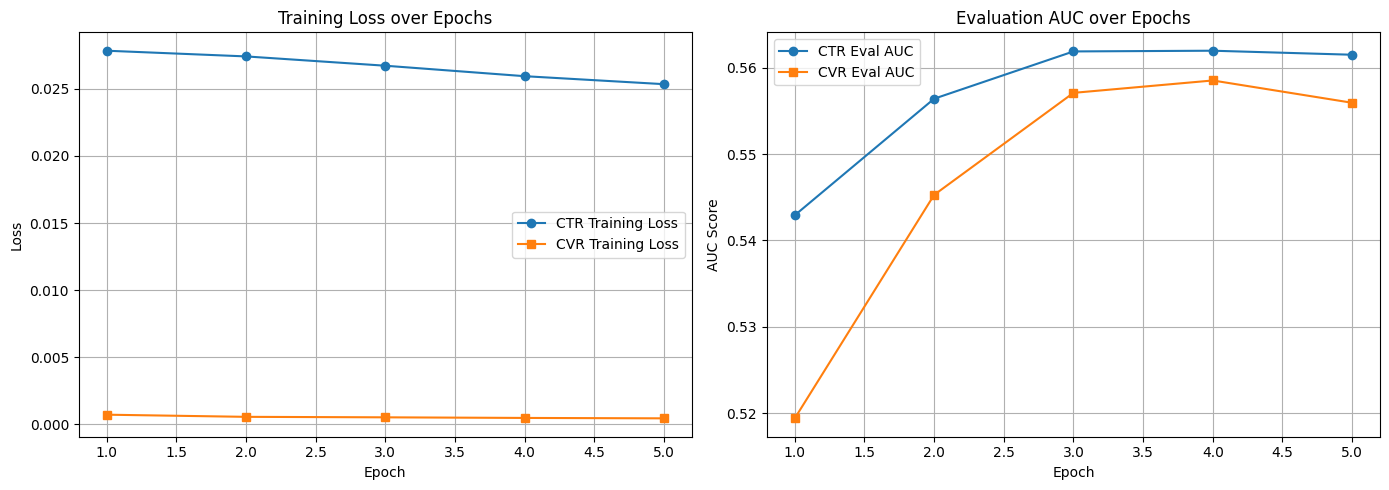

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 获取实际跑的 Epoch 数量（处理被早停截断的情况）
actual_epochs = len(history['loss_ctr'])

# 绘制 Loss 曲线
axes[0].plot(range(1, actual_epochs+1), history['loss_ctr'], marker='o', label='CTR Training Loss')
axes[0].plot(range(1, actual_epochs+1), history['loss_cvr'], marker='s', label='CVR Training Loss')
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 绘制 AUC 曲线
axes[1].plot(range(1, actual_epochs+1), history['auc_ctr'], marker='o', label='CTR Eval AUC')
axes[1].plot(range(1, actual_epochs+1), history['auc_cvr'], marker='s', label='CVR Eval AUC')
axes[1].set_title('Evaluation AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()